Interpretation of two best models for every metric. Boosting and not boosting.

# Libraries

In [42]:
import pandas as pd
from sklearn.metrics import f1_score
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from catboost import CatBoostClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

In [34]:
# train/test split
import sys
sys.path.insert(1, '../utils_functionality/split_utils/')
from split_tools import get_train_test

In [27]:
RANDOM_STATE = 42

# Choosing best models 

In [ ]:
df_metrics = pd.read_excel(r'..\results\metrics_modelling2.xlsx', index_col=[0])

## Splashing

In [19]:
df_metrics[df_metrics['target']=='splashing'].sort_values(by='f1', ascending=False).head(6)

,dataset,target,model,accuracy,f1,precision,recall,roc_auc,optuna_flg
255,df_modelling_dimensionless,splashing,svc_smote_splashing_onehot,0.920000,0.938776,0.920000,0.958333,0.905093,1
256,df_modelling_dimensionless_pf,splashing,svc_smote_splashing_onehot,0.920000,0.938776,0.920000,0.958333,0.905093,1
260,df_modelling_no_multicollinearity_pf,splashing,svc_smote_splashing_ordenc,0.920000,0.938776,0.920000,0.958333,0.905093,1
259,df_modelling_dimensionless,splashing,svc_smote_splashing_ordenc,0.920000,0.937500,0.937500,0.937500,0.913194,1
223,df_modelling_dimensionless,splashing,svc_smote_splashing_onehot,0.906667,0.929293,0.901961,0.958333,0.886574,0
252,df_modelling_dimensionless_pf,splashing,catboostclassifier_smote_splashing,0.906667,0.927835,0.918367,0.937500,0.894676,1


Best sklearn model:

In [18]:
df_metrics.iloc[255]

dataset       df_modelling_dimensionless
target                         splashing
model         svc_smote_splashing_onehot
accuracy                            0.92
f1                              0.938776
precision                           0.92
recall                          0.958333
roc_auc                         0.905093
optuna_flg                             1
Name: 255, dtype: object

Best boosting model

In [20]:
df_metrics.iloc[252]

dataset            df_modelling_dimensionless_pf
target                                 splashing
model         catboostclassifier_smote_splashing
accuracy                                0.906667
f1                                      0.927835
precision                               0.918367
recall                                    0.9375
roc_auc                                 0.894676
optuna_flg                                     1
Name: 252, dtype: object

## Net impact

In [21]:
df_metrics[df_metrics['target']=='net_impact'].sort_values(by='f1', ascending=False).head(6)

,dataset,target,model,accuracy,f1,precision,recall,roc_auc,optuna_flg
233,df_modelling_dimensionless_pf,net_impact,catboostclassifier_net_impact,0.960000,0.923077,0.947368,0.9,0.940909,1
232,df_modelling_dimensionless,net_impact,catboostclassifier_net_impact,0.960000,0.923077,0.947368,0.9,0.940909,1
39,df_modelling_full,net_impact,catboostclassifier_net_impact,0.946667,0.900000,0.900000,0.9,0.931818,0
79,df_modelling_dimensionless,net_impact,catboostclassifier_net_impact,0.946667,0.900000,0.900000,0.9,0.931818,0
119,df_modelling_dimensionless_pf,net_impact,catboostclassifier_net_impact,0.946667,0.900000,0.900000,0.9,0.931818,0
238,df_modelling_no_multicollinearity_pf,net_impact,kneighborsclassifier_net_impact_onehot,0.946667,0.900000,0.900000,0.9,0.931818,1


Best sklearn model:

In [22]:
df_metrics.iloc[238]

dataset         df_modelling_no_multicollinearity_pf
target                                    net_impact
model         kneighborsclassifier_net_impact_onehot
accuracy                                    0.946667
f1                                               0.9
precision                                        0.9
recall                                           0.9
roc_auc                                     0.931818
optuna_flg                                         1
Name: 238, dtype: object

Best boosting model

In [23]:
df_metrics.iloc[233]

dataset       df_modelling_dimensionless_pf
target                           net_impact
model         catboostclassifier_net_impact
accuracy                               0.96
f1                                 0.923077
precision                          0.947368
recall                                  0.9
roc_auc                            0.940909
optuna_flg                                1
Name: 233, dtype: object

# Model interpretation

## Splashing

SVM

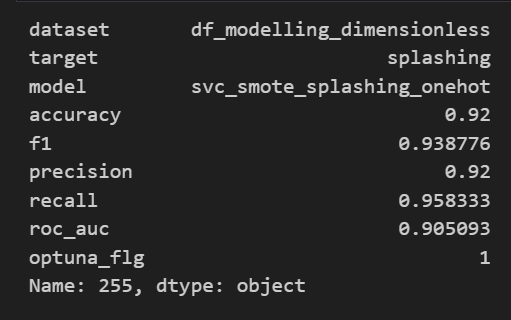

In [38]:
target = 'splashing'
train, test = get_train_test(
    dataset_filename=df_metrics.iloc[255]['dataset'],
    target=target)

In [160]:
num_features = ['Re', 'We', 'We_Re',
                         'inclination',
                        'particle_liquid_density_ratio',
                        'particle_droplet_diameter_ratio']
cat_features=['wettability']

pipeline = []
numeric_transformer = Pipeline(steps=[("scaler", StandardScaler())])
transformers = [("num", numeric_transformer, num_features)]
categorical_transformer = Pipeline(
            steps=[('onehot', OneHotEncoder(handle_unknown="ignore"))])
transformers.append(('cat', categorical_transformer, cat_features))
preprocessor = ColumnTransformer(transformers=transformers)
pipeline.append(('preprocessor', preprocessor))
smt = SMOTE(random_state=RANDOM_STATE)
pipeline.append(('smt', smt))
pipeline.append(('svc', SVC(**{
      "C": 25841.00544482914,
      "kernel": "rbf",
      "gamma": 0.008229949100645798,
      "coef0": -0.6211652044901957,
    })))
pipeline = Pipeline(pipeline)

pipeline.fit(train.drop(columns=['splashing']), y=train['splashing'])
preds = pipeline.predict(test.drop(columns=['splashing']))
f1_score(preds, test['splashing'])

0.9166666666666666

Boosting models

In [161]:
df_metrics.iloc[252]

dataset            df_modelling_dimensionless_pf
target                                 splashing
model         catboostclassifier_smote_splashing
accuracy                                0.906667
f1                                      0.927835
precision                               0.918367
recall                                    0.9375
roc_auc                                 0.894676
optuna_flg                                     1
Name: 252, dtype: object

In [164]:
pipeline = [('smt', SMOTE(random_state=RANDOM_STATE))]
pipeline.append(('model', CatBoostClassifier(**{
      "objective": "CrossEntropy",
      "colsample_bylevel": 0.0953763687812177,
      "depth": 7,
      "boosting_type": "Plain",
      "bootstrap_type": "Bernoulli",
      "subsample": 0.719211743393754,
      "verbose": False
    })))
pipeline = Pipeline(pipeline)
pipeline.fit(train.drop(columns=['splashing']), y=train['splashing'])
preds = pipeline.predict(test.drop(columns=['splashing']))
f1_score(preds, test['splashing'])

C:\Users\dimaz\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\catboost\core.py:1419: FutureWarning: iteritems is deprecated and will be removed in a future version. Use .items instead.
  self._init_pool(data, label, cat_features, text_features, embedding_features, embedding_features_data, pairs, weight,
C:\Users\dimaz\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\catboost\core.py:1419: FutureWarning: iteritems is deprecated and will be removed in a future version. Use .items instead.
  self._init_pool(data, label, cat_features, text_features, embedding_features, embedding_features_data, pairs, weight,


0.888888888888889